(248, 334, 334)


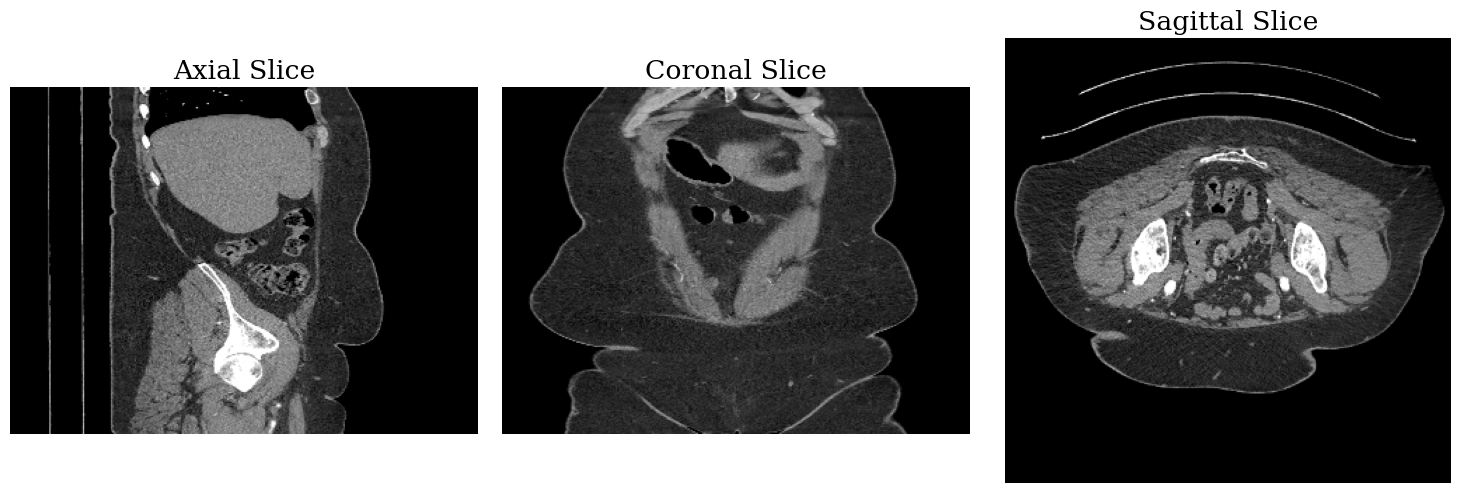

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl



# Use Times New Roman or similar serif font
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.size'] = 16  # Adjust caption size

# Load CT and prediction volumes
ct_path = "/u/home/hodo/Documents/ct_kits.nii.gz"
pred_path = "/u/home/hodo/Documents/prediction_kits_base.nii.gz"

ct_img = nib.load(ct_path).get_fdata()
pred_img = nib.load(pred_path).get_fdata().astype(int)

# Normalize CT for visualization
ct_img = (ct_img - np.min(ct_img)) / (np.max(ct_img) - np.min(ct_img))
print(ct_img.shape)

# Class label → color map (skip class 0)
class_names_colors = {
    1: ("Spleen", "#8eac84"),
    2: ("Right Kidney", "#e9d899"),
    3: ("Left Kidney", "#a47e68"),
    4: ("Gallbladder", "#8ab5cf"),
    5: ("Esophagus", "#c17055"),
    6: ("Liver", "#c98a6a"),
    7: ("Stomach", "#aeeb9a"),
    8: ("Aorta", "#ad705c"),
    9: ("Inferior Vena Cava", "#e1f551"),
    10: ("Portal Vein & Splenic Vein", "#4a400f"),
    11: ("Pancreas", "#fdfbdf"),
    12: ("Right Adrenal Gland", "#e1dd61"),
    13: ("Left Adrenal Gland", "#c9c8e8")
}

# Create a color map and norm
num_classes = max(class_names_colors.keys())
color_list = ['none'] + [class_names_colors[i][1] for i in range(1, num_classes + 1)]
cmap = mcolors.ListedColormap(color_list)
bounds = list(np.arange(num_classes + 2))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Slice indices
first_axial = 235
first_coronal = 225
mid_sagittal = ct_img.shape[0] // 4

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.flipud(ct_img[:, :, first_axial]), cmap='gray')
axes[0].imshow(np.flipud(pred_img[:, :, first_axial]), cmap=cmap, norm=norm, alpha=0.5)
axes[0].set_title("Axial Slice")
axes[0].axis('off')

axes[1].imshow(np.flipud(ct_img[:, first_coronal, :]), cmap='gray')
axes[1].imshow(np.flipud(pred_img[:, first_coronal, :]), cmap=cmap, norm=norm, alpha=0.5)
axes[1].set_title("Coronal Slice")
axes[1].axis('off')

axes[2].imshow(ct_img[mid_sagittal, :, :], cmap='gray')
axes[2].imshow(pred_img[mid_sagittal, :, :], cmap=cmap, norm=norm, alpha=0.5)
axes[2].set_title("Sagittal Slice")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("ct_prediction_overlay_kits.pdf", bbox_inches='tight')
plt.show()


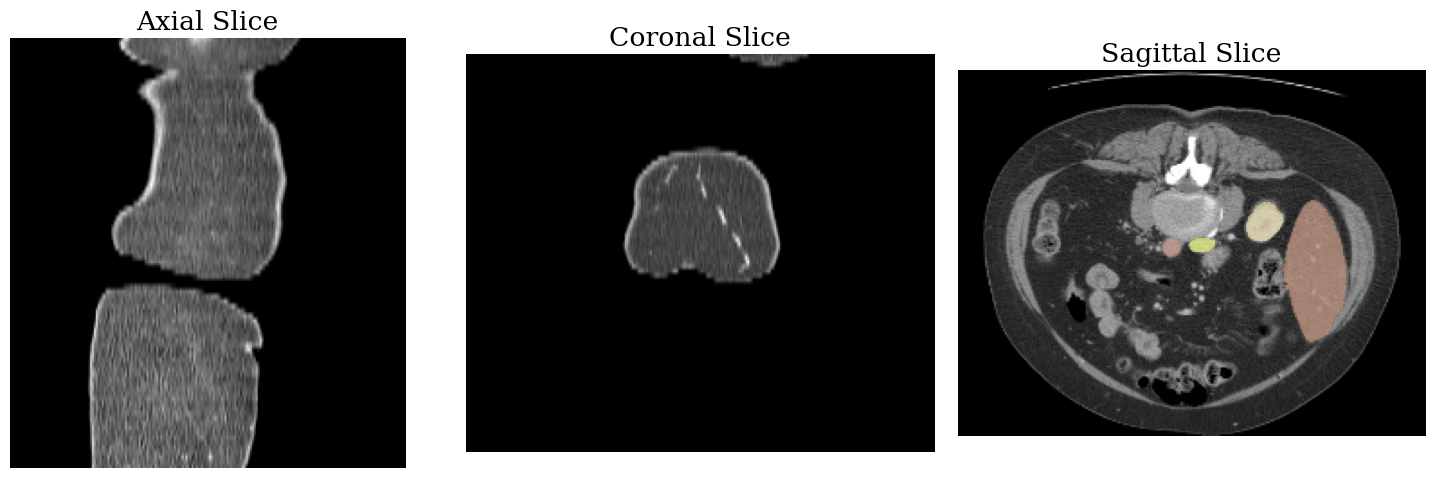

In [17]:

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl

# Set font properties
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.size'] = 16  # Enlarge captions

# Updated file paths
ct_path = "/u/home/hodo/Documents/ct_unetr.nii.gz"
pred_path = "/u/home/hodo/Documents/prediction_unetr.nii.gz"

# Load CT and prediction volumes
ct_img = nib.load(ct_path).get_fdata()
pred_img = nib.load(pred_path).get_fdata().astype(int)

# Normalize CT for visualization
ct_img = (ct_img - np.min(ct_img)) / (np.max(ct_img) - np.min(ct_img))

# Class label → color map (skip class 0)
class_names_colors = {
    1: ("Spleen", "#8eac84"),
    2: ("Right Kidney", "#e9d899"),
    3: ("Left Kidney", "#a47e68"),
    4: ("Gallbladder", "#8ab5cf"),
    5: ("Esophagus", "#c17055"),
    6: ("Liver", "#c98a6a"),
    7: ("Stomach", "#aeeb9a"),
    8: ("Aorta", "#ad705c"),
    9: ("Inferior Vena Cava", "#e1f551"),
    10: ("Portal Vein & Splenic Vein", "#4a400f"),
    11: ("Pancreas", "#fdfbdf"),
    12: ("Right Adrenal Gland", "#e1dd61"),
    13: ("Left Adrenal Gland", "#c9c8e8")
}

# Create color map and normalization
num_classes = max(class_names_colors.keys())
color_list = ['none'] + [class_names_colors[i][1] for i in range(1, num_classes + 1)]
cmap = mcolors.ListedColormap(color_list)
bounds = list(np.arange(num_classes + 2))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Choose slice indices
first_axial = 235
first_coronal = 195
mid_sagittal = ct_img.shape[0] // 2

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial (flipped vertically)
axes[0].imshow(np.flipud(ct_img[:, :, first_axial]), cmap='gray')
axes[0].imshow(np.flipud(pred_img[:, :, first_axial]), cmap=cmap, norm=norm, alpha=0.5)
axes[0].set_title("Axial Slice")
axes[0].axis('off')

# Coronal (flipped vertically)
axes[1].imshow(np.flipud(ct_img[:, first_coronal, :]), cmap='gray')
axes[1].imshow(np.flipud(pred_img[:, first_coronal, :]), cmap=cmap, norm=norm, alpha=0.5)
axes[1].set_title("Coronal Slice")
axes[1].axis('off')

# Sagittal (no flip)
axes[2].imshow(ct_img[mid_sagittal, :, :], cmap='gray')
axes[2].imshow(pred_img[mid_sagittal, :, :], cmap=cmap, norm=norm, alpha=0.5)
axes[2].set_title("Sagittal Slice")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("ct_prediction_overlay_unetr.pdf", bbox_inches='tight')
plt.show()


(248, 334, 334)


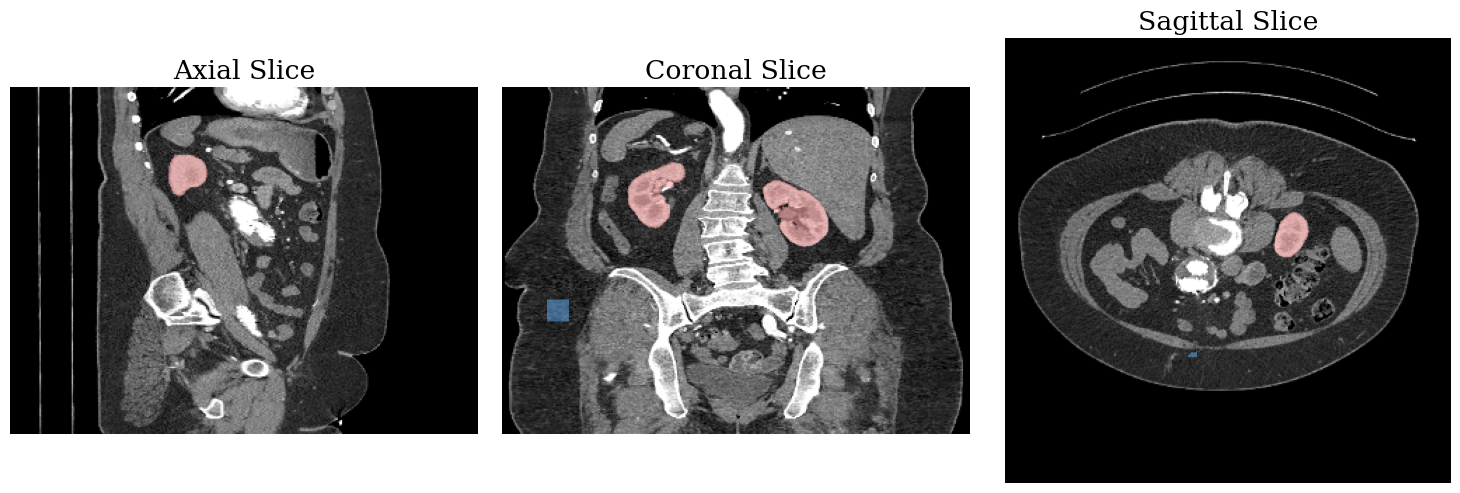

In [17]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl

# Use Times New Roman or similar serif font
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.size'] = 16  # Adjust caption size

# Load CT and prediction volumes
ct_path = "/u/home/hodo/Documents/ct_kits.nii.gz"
pred_path = "/u/home/hodo/Documents/prediction_kits_base.nii.gz"

ct_img = nib.load(ct_path).get_fdata()
pred_img = nib.load(pred_path).get_fdata().astype(int)

# Normalize CT for visualization
ct_img = (ct_img - np.min(ct_img)) / (np.max(ct_img) - np.min(ct_img))
print(ct_img.shape)

# Define class label → name and color mapping
class_names_colors = {
    1: ("Kidney", "#ff9999"),
    2: ("Mass)", "#66b3ff"),
    3: ("Tumor ", "#99ff99"),

}

# Create colormap and normalization
num_classes = max(class_names_colors.keys())
color_list = ['none'] + [class_names_colors[i][1] for i in range(1, num_classes + 1)]
cmap = mcolors.ListedColormap(color_list)
bounds = list(np.arange(num_classes + 2))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Slice indices
first_axial = 130
first_coronal = 140
mid_sagittal = int( ct_img.shape[0] // 1.8)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.flipud(ct_img[:, :, first_axial]), cmap='gray')
axes[0].imshow(np.flipud(pred_img[:, :, first_axial]), cmap=cmap, norm=norm, alpha=0.5)
axes[0].set_title("Axial Slice")
axes[0].axis('off')

axes[1].imshow(np.flipud(ct_img[:, first_coronal, :]), cmap='gray')
axes[1].imshow(np.flipud(pred_img[:, first_coronal, :]), cmap=cmap, norm=norm, alpha=0.5)
axes[1].set_title("Coronal Slice")
axes[1].axis('off')

axes[2].imshow(ct_img[mid_sagittal, :, :], cmap='gray')
axes[2].imshow(pred_img[mid_sagittal, :, :], cmap=cmap, norm=norm, alpha=0.5)
axes[2].set_title("Sagittal Slice")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("ct_prediction_overlay_kits.pdf", bbox_inches='tight')
plt.show()


(145, 272, 272)


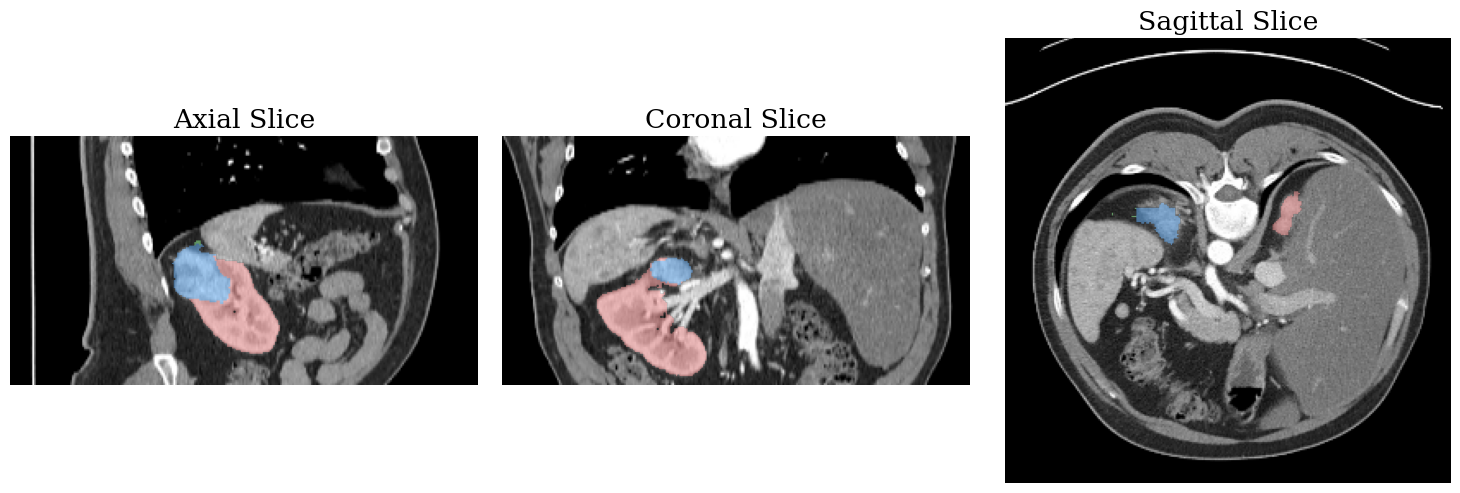

In [18]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl

# Use Times New Roman or similar serif font
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.size'] = 16  # Adjust caption size

# Load CT and prediction volumes
ct_path = "/u/home/hodo/Documents/ct_kits_1.nii.gz"
pred_path = "/u/home/hodo/Documents/prediction_kits_base_1.nii.gz"

ct_img = nib.load(ct_path).get_fdata()
pred_img = nib.load(pred_path).get_fdata().astype(int)

# Normalize CT for visualization
ct_img = (ct_img - np.min(ct_img)) / (np.max(ct_img) - np.min(ct_img))
print(ct_img.shape)

# Define class label → name and color mapping
class_names_colors = {
    1: ("Kidney", "#ff9999"),
    2: ("Mass)", "#66b3ff"),
    3: ("Tumor ", "#99ff99"),

}

# Create colormap and normalization
num_classes = max(class_names_colors.keys())
color_list = ['none'] + [class_names_colors[i][1] for i in range(1, num_classes + 1)]
cmap = mcolors.ListedColormap(color_list)
bounds = list(np.arange(num_classes + 2))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Slice indices
first_axial = 80
first_coronal = 140
mid_sagittal = int( ct_img.shape[0] // 1.8)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.flipud(ct_img[:, :, first_axial]), cmap='gray')
axes[0].imshow(np.flipud(pred_img[:, :, first_axial]), cmap=cmap, norm=norm, alpha=0.5)
axes[0].set_title("Axial Slice")
axes[0].axis('off')

axes[1].imshow(np.flipud(ct_img[:, first_coronal, :]), cmap='gray')
axes[1].imshow(np.flipud(pred_img[:, first_coronal, :]), cmap=cmap, norm=norm, alpha=0.5)
axes[1].set_title("Coronal Slice")
axes[1].axis('off')

axes[2].imshow(ct_img[mid_sagittal, :, :], cmap='gray')
axes[2].imshow(pred_img[mid_sagittal, :, :], cmap=cmap, norm=norm, alpha=0.5)
axes[2].set_title("Sagittal Slice")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("ct_prediction_overlay_kits_1.pdf", bbox_inches='tight')
plt.show()
